# Analise Exploratória dos Dados

In [1]:
#pip install matplotlib seaborn scikit-learn streamlit openpyxl -q

In [2]:
import pandas as pd

# O parâmetro sheet_name=None diz ao Pandas para carregar TUDO
todas_as_folhas = pd.read_excel('data/base_dados_2024.xlsx', sheet_name=None)

# Para ver os nomes de todas as folhas que foram carregadas:
print(todas_as_folhas.keys())


# Agora, pode separar cada folha no seu próprio DataFrame usando o nome exato da folha:
df_2022 = todas_as_folhas['PEDE2022']


dict_keys(['PEDE2022', 'PEDE2023', 'PEDE2024'])


# Analisando tipo de dados de cada DataFrame

In [3]:
print("-"*60)
df_2022.info()
print("-"*60)

------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 860 entries, 0 to 859
Data columns (total 42 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   RA                     860 non-null    object 
 1   Fase                   860 non-null    int64  
 2   Turma                  860 non-null    object 
 3   Nome                   860 non-null    object 
 4   Ano nasc               860 non-null    int64  
 5   Idade 22               860 non-null    int64  
 6   Gênero                 860 non-null    object 
 7   Ano ingresso           860 non-null    int64  
 8   Instituição de ensino  860 non-null    object 
 9   Pedra 20               323 non-null    object 
 10  Pedra 21               462 non-null    object 
 11  Pedra 22               860 non-null    object 
 12  INDE 22                860 non-null    float64
 13  Cg                     860 non-null    int64  
 1

In [4]:
nulos_por_coluna = df_2022.isnull().sum()
nulos_por_coluna

RA                         0
Fase                       0
Turma                      0
Nome                       0
Ano nasc                   0
Idade 22                   0
Gênero                     0
Ano ingresso               0
Instituição de ensino      0
Pedra 20                 537
Pedra 21                 398
Pedra 22                   0
INDE 22                    0
Cg                         0
Cf                         0
Ct                         0
Nº Av                      0
Avaliador1                 0
Rec Av1                    0
Avaliador2                 0
Rec Av2                    0
Avaliador3               326
Rec Av3                    0
Avaliador4               550
Rec Av4                  564
IAA                        0
IEG                        0
IPS                        0
Rec Psicologia             0
IDA                        0
Matem                      2
Portug                     2
Inglês                   577
Indicado                   0
Atingiu PV    

# Procurando Inconsistência nos dados

## Análise de Dados Faltantes (Nulls)
O primeiro passo na validação da base é entender o volume e o impacto dos dados nulos. Analisar apenas a quantidade absoluta não nos dá a dimensão real do problema, por isso o foco é na **porcentagem de dados faltantes**. 

In [5]:
print("ANÁLISE PROFUNDA DE VALORES NULOS")
# Em vez de só mostrar a quantidade, vamos calcular a porcentagem de nulos
nulos_qtd = df_2022.isnull().sum()
nulos_perc = (df_2022.isnull().sum() / len(df_2022)) * 100

df_nulos = pd.DataFrame({'Qtd_Nulos': nulos_qtd, 'Porcentagem (%)': nulos_perc})
# Filtra apenas quem tem nulos e ordena do maior para o menor
df_nulos_filtrado = df_nulos[df_nulos['Qtd_Nulos'] > 0].sort_values(by='Qtd_Nulos', ascending=False)

print("Visão Geral de Dados Faltantes:")
print(df_nulos_filtrado)
print("\n\n" + "-"*60)


ANÁLISE PROFUNDA DE VALORES NULOS
Visão Geral de Dados Faltantes:
            Qtd_Nulos  Porcentagem (%)
Inglês            577        67.093023
Rec Av4           564        65.581395
Avaliador4        550        63.953488
Pedra 20          537        62.441860
Pedra 21          398        46.279070
Avaliador3        326        37.906977
Matem               2         0.232558
Portug              2         0.232558


------------------------------------------------------------


Precisamos investigar anomalias pontuais (como alunos específicos sem nota em matérias base como podemos ver no resultado eciste dois alunos sem nota de português e matematica) para definir se a melhor estratégia será a imputação de dados (preencher com média/zero) ou o descarte da linha, evitando destruir a volumetria do dataset.

In [6]:
print("\nExiste 2 alunos específicos sem nota de Matemática e Português:")
# Filtra o DataFrame mostrando as linhas exatas onde a nota é nula
alunos_sem_nota = df_2022[df_2022['Matem'].isnull() | df_2022['Portug'].isnull()]
print(alunos_sem_nota[['RA', 'Fase', 'Matem', 'Portug', 'INDE 22']])



Existe 2 alunos específicos sem nota de Matemática e Português:
         RA  Fase  Matem  Portug  INDE 22
287  RA-288     3    NaN     NaN    4.097
293  RA-294     3    NaN     NaN    5.031


## Inconsistências em Variáveis Categóricas (Verificação Automatizada)
Para evitar a checagem manual de cada variável, criamos um loop que varre todo o DataFrame em busca de colunas do tipo texto (`object`). 

Aplicamos um limite para exibir apenas variáveis que possuam menos de 20 valores únicos. Isso limpa a saída do nosso terminal, filtrando automaticamente.

In [7]:
print("-"*60)
print("INCONSISTÊNCIAS EM TEXTOS (VARREDURA AUTOMÁTICA)")
print("-"*60)

# Seleciona TODAS as colunas que são de texto (object)
colunas_texto = df_2022.select_dtypes(include=['object']).columns

# Passa por cada uma das colunas encontradas
for col in colunas_texto:
    # Conta quantos valores diferentes existem na coluna
    qtd_unicos = df_2022[col].nunique(dropna=False)
    
    # Se tiver menos de 20 valores únicos, é uma categoria! Vamos investigar:
    if qtd_unicos < 20:
        print(f"\n[+] Coluna: '{col}' ({qtd_unicos} categorias únicas)")
        print(df_2022[col].value_counts(dropna=False))
        print("-" * 30)
    else:
        # Se tiver muitos valores, ele apenas avisa e pula para não sujar a tela
        print(f"\n[-] Coluna: '{col}' ignorada na visão detalhada ({qtd_unicos} valores únicos - Provável ID ou Texto Livre)")

------------------------------------------------------------
INCONSISTÊNCIAS EM TEXTOS (VARREDURA AUTOMÁTICA)
------------------------------------------------------------

[-] Coluna: 'RA' ignorada na visão detalhada (860 valores únicos - Provável ID ou Texto Livre)

[-] Coluna: 'Turma' ignorada na visão detalhada (24 valores únicos - Provável ID ou Texto Livre)

[-] Coluna: 'Nome' ignorada na visão detalhada (860 valores únicos - Provável ID ou Texto Livre)

[+] Coluna: 'Gênero' (2 categorias únicas)
Gênero
Menina    457
Menino    403
Name: count, dtype: int64
------------------------------

[+] Coluna: 'Instituição de ensino' (3 categorias únicas)
Instituição de ensino
Escola Pública    752
Rede Decisão      106
Escola JP II        2
Name: count, dtype: int64
------------------------------

[+] Coluna: 'Pedra 20' (5 categorias únicas)
Pedra 20
NaN         537
Ametista    182
Topázio      61
Ágata        56
Quartzo      24
Name: count, dtype: int64
------------------------------

[+] 

## Validação de Outliers e Regra de Negócio
Antes de tratar valores que parecem absurdos (outliers), é essencial cruzar os dados com as regras de negócio da instituição. 

Vamos analisar a distribuição das notas e da 'Idade' usando estatística descritiva (Mínimo, Máximo e Média). O foco principal aqui é a variável `Defas` (Defasagem Escolar). Encontrar valores negativos geralmente indica um erro de digitação no sistema, mas precisamos comprovar se, neste contexto pedagógico, os números negativos não representam um indicador real da trajetória do aluno.

In [8]:
print("\n\n" + "-"*60)
print("COMPROVANDO A REGRA DE NEGÓCIO (DEFASAGEM)")
print("-"*60)

print("\nResumo Estatístico focado em limites absurdos (Min e Max):")
colunas_numericas = ['Idade 22', 'INDE 22', 'Matem', 'Portug', 'Inglês', 'Defas']
print(df_2022[colunas_numericas].describe().loc[['min', 'max', 'mean']])

print("\nDistribuição detalhada da Defasagem (Valores negativos):")
# Mostra exatamente quantas crianças têm defasagem -5, -4, -3, etc.
# O sort_index() garante que a visualização fique ordenada do -5 até o +2
print(df_2022['Defas'].value_counts().sort_index())



------------------------------------------------------------
COMPROVANDO A REGRA DE NEGÓCIO (DEFASAGEM)
------------------------------------------------------------

Resumo Estatístico focado em limites absurdos (Min e Max):
       Idade 22   INDE 22      Matem     Portug     Inglês     Defas
min    7.000000  3.032000   0.000000   0.000000   0.000000 -5.000000
max   21.000000  9.442000  10.000000  10.000000  10.000000  2.000000
mean  12.138372  7.036176   5.806876   6.320979   5.881272 -0.943023

Distribuição detalhada da Defasagem (Valores negativos):
Defas
-5      1
-4      4
-3     23
-2    163
-1    410
 0    247
 1      9
 2      3
Name: count, dtype: int64


# Resumo da Base de 2022
O que precisará ser transformado nela:

Gênero (Menino/Menina -> Masculino/Feminino): Padronização categórica para garantir compatibilidade com os anos de 2023 e 2024, evitando a fragmentação da variável no modelo.

Instituição (Rede Decisão/Escola JP II -> Privada): Agrupamento de nomes de instituições específicas em uma categoria macro ("Privada") para alinhar com o dicionário de dados das pesquisas mais recentes.

Notas faltantes de Mat/Por e Inglês (Preencher): Imputação de valor 0 nos campos nulos. No caso de Inglês, a ação visa manter a volumetria da base (visto que 67% dos dados são nulos por regra de fase escolar), e em Mat/Por para tratar casos isolados de ausência de nota.

Limpar o texto da Fase ideal: Aplicação de string split e limpeza de espaços duplos para remover informações redundantes entre parênteses. O objetivo é isolar apenas o identificador da fase (ex: "ALFA", "Fase 1"), transformando-a em uma variável ordinal limpa.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 14

# Perfil Demográfico (Gênero e Idade)

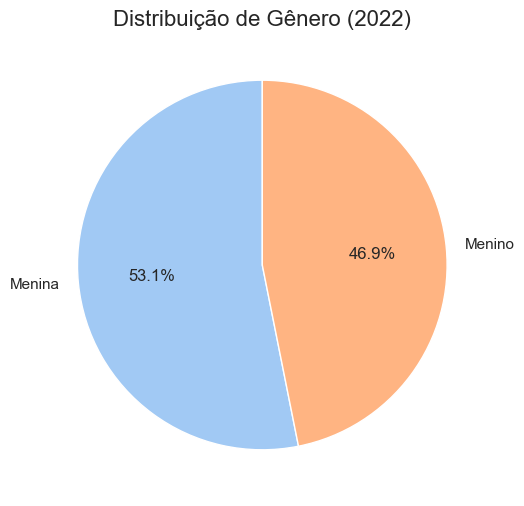

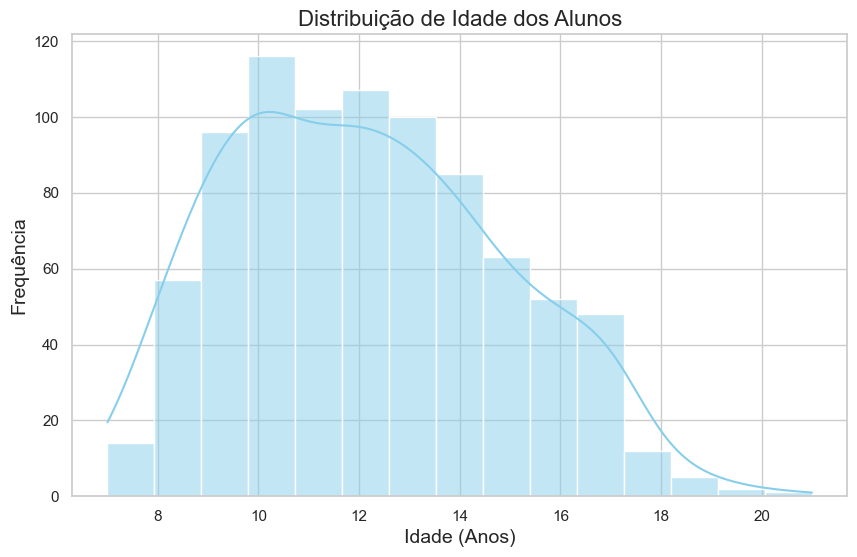

In [ ]:

plt.figure(figsize=(8, 6))
genero_counts = df_2022['Gênero'].value_counts()
plt.pie(genero_counts, labels=genero_counts.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('pastel'))
plt.title("Distribuição de Gênero (2022)")
plt.show()

plt.figure(figsize=(10, 6))
sns.histplot(df_2022['Idade 22'], bins=15, kde=True, color='skyblue')
plt.title("Distribuição de Idade dos Alunos")
plt.xlabel("Idade (Anos)")
plt.ylabel("Frequência")
plt.show()

# Análise de Performance (INDE e Indicadores)

<>:7: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<>:7: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
C:\Users\zirn1\AppData\Local\Temp\ipykernel_54600\65989728.py:7: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
  df_2022['Fase'] = df_2022['Fase ideal'].str.split(' \(').str[0].str.strip()
C:\Users\zirn1\AppData\Local\Temp\ipykernel_54600\65989728.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


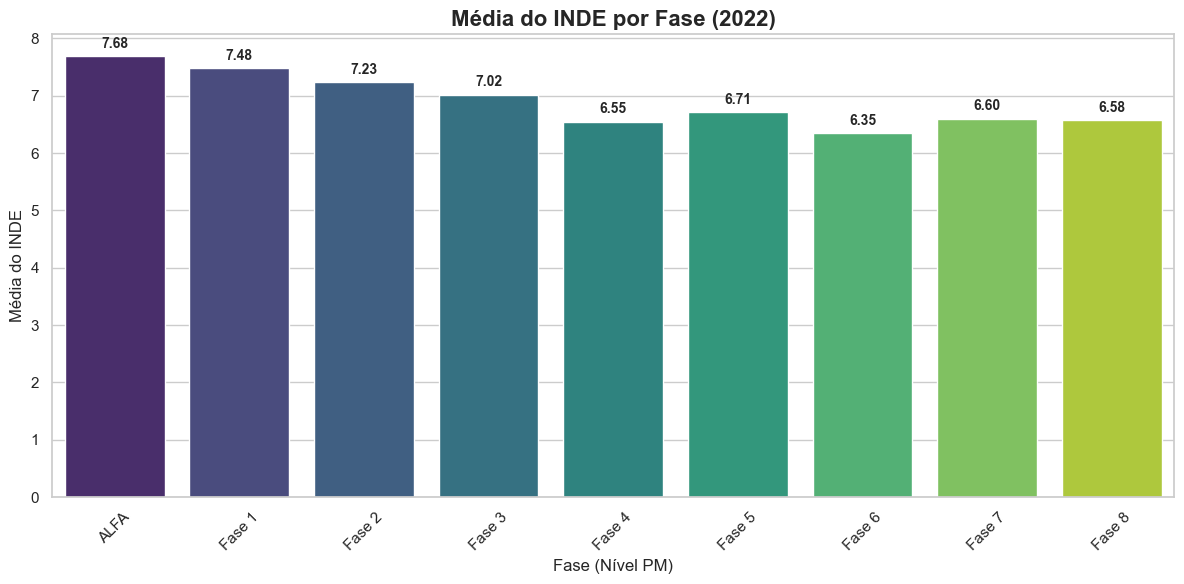

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df_2022['Fase'] = df_2022['Fase ideal'].str.split(' \(').str[0].str.strip()
df_2022.loc[df_2022['Fase'].str.contains('ALFA', na=False), 'Fase'] = 'ALFA'

df_2022['INDE 22'] = pd.to_numeric(df_2022['INDE 22'], errors='coerce')

order_fase = ['ALFA', 'Fase 1', 'Fase 2', 'Fase 3', 'Fase 4', 'Fase 5', 'Fase 6', 'Fase 7', 'Fase 8']

plt.figure(figsize=(12, 6))

sns.barplot(
    x='Fase', 
    y='INDE 22', 
    data=df_2022, 
    order=order_fase, 
    palette='viridis', 
    estimator=np.mean, 
    errorbar=None
)

plt.title("Média do INDE por Fase (2022)", fontsize=16, fontweight='bold')
plt.xlabel("Fase (Nível PM)", fontsize=12)
plt.ylabel("Média do INDE", fontsize=12)
plt.xticks(rotation=45)

ax = plt.gca()
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points',
                fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# Jornada e Classificação (Pedras)

C:\Users\zirn1\AppData\Local\Temp\ipykernel_54600\500385228.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Pedra 22', data=df_2022, order=order_pedra, palette='coolwarm')


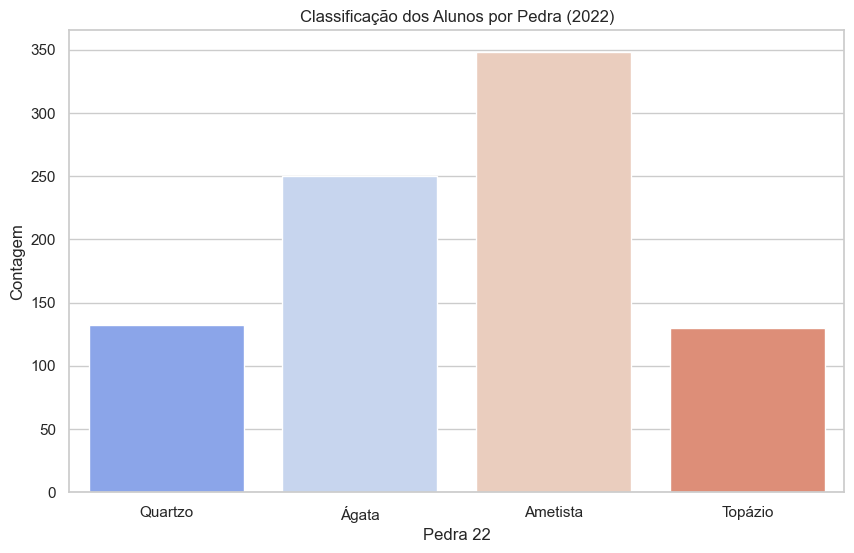

In [ ]:

order_pedra = ['Quartzo', 'Ágata', 'Ametista', 'Topázio']

plt.figure(figsize=(10, 6))
sns.countplot(x='Pedra 22', data=df_2022, order=order_pedra, palette='coolwarm')
plt.title("Classificação dos Alunos por Pedra (2022)")
plt.xlabel("Pedra 22")
plt.ylabel("Contagem")
plt.show()

# Matérias Core (Matemática vs Português)

C:\Users\zirn1\AppData\Local\Temp\ipykernel_54600\1646247146.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Matéria', y='Média', data=notas_core, palette='Set2', errorbar=None)


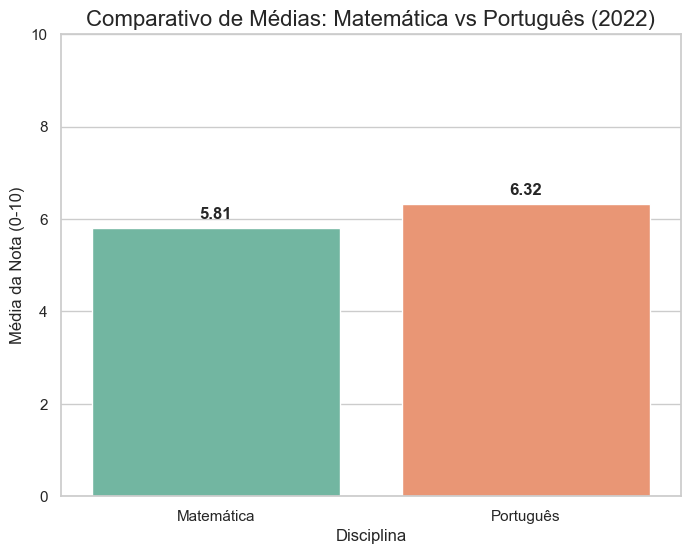

In [ ]:

notas_core = df_2022[['Matem', 'Portug']].mean().reset_index()

notas_core.columns = ['Matéria', 'Média']
notas_core['Matéria'] = notas_core['Matéria'].replace({
    'Matem': 'Matemática', 
    'Portug': 'Português'
})

plt.figure(figsize=(8, 6))
sns.barplot(x='Matéria', y='Média', data=notas_core, palette='Set2', errorbar=None)

plt.title("Comparativo de Médias: Matemática vs Português (2022)", fontsize=16)
plt.ylabel("Média da Nota (0-10)", fontsize=12)
plt.xlabel("Disciplina", fontsize=12)
plt.ylim(0, 10) 

for i, v in enumerate(notas_core['Média']):
    plt.text(i, v + 0.2, f"{v:.2f}", ha='center', fontweight='bold')

plt.show()

# Comparativo de Desempenho

C:\Users\zirn1\AppData\Local\Temp\ipykernel_54600\2928713402.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Gênero', y='INDE 22', data=df_2022, palette='pastel')


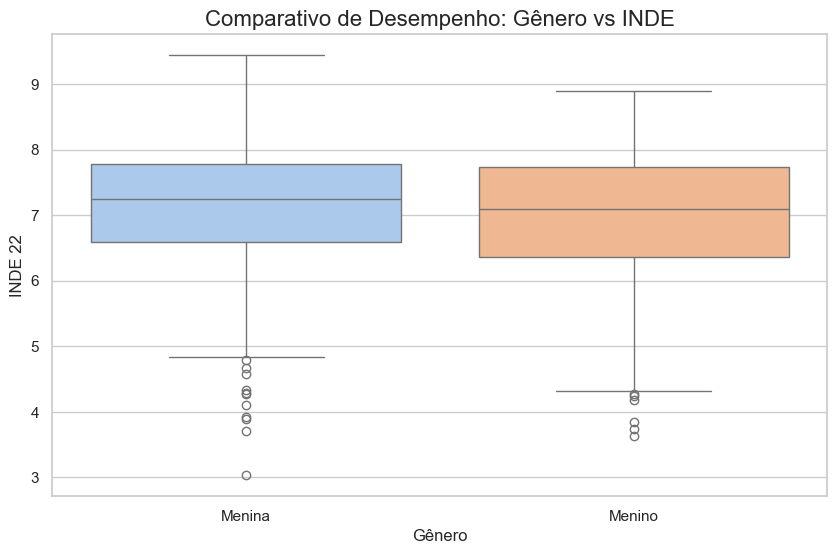

In [21]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Gênero', y='INDE 22', data=df_2022, palette='pastel')

plt.title("Comparativo de Desempenho: Gênero vs INDE", fontsize=16)
plt.ylabel("INDE 22")
plt.show()

# Ponto de virada

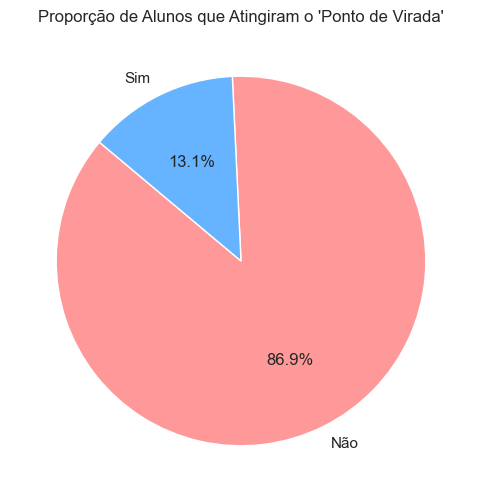

In [ ]:

plt.figure(figsize=(8, 6))
pv_counts = df_2022['Atingiu PV'].value_counts()

plt.pie(pv_counts, labels=pv_counts.index, autopct='%1.1f%%', startangle=140, colors=['#ff9999','#66b3ff'])
plt.title("Proporção de Alunos que Atingiram o 'Ponto de Virada'")
plt.show()

#  Relação Idade vs INDE com distinção de Pedra

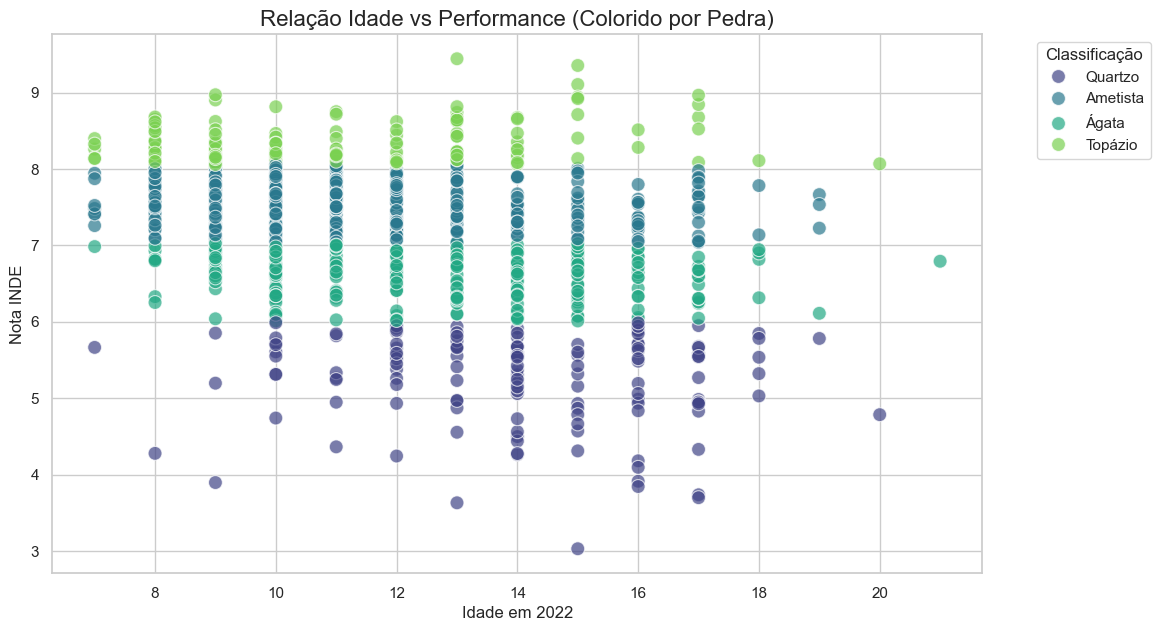

In [ ]:
plt.figure(figsize=(12, 7))
sns.scatterplot(x='Idade 22', y='INDE 22', hue='Pedra 22', data=df_2022, palette='viridis', s=100, alpha=0.7)

plt.title("Relação Idade vs Performance (Colorido por Pedra)", fontsize=16)
plt.xlabel("Idade em 2022")
plt.ylabel("Nota INDE")
plt.legend(title='Classificação', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()